In [1]:
from dataset import *
from utils import *

Создадим экземпляр конфига - он содается один на каждую отдельную модель и управляет всем: от пути к целевой папке до параметра seed

In [2]:
cfg = MultiModelConfig()

# посмотрим на базовый конфиг
cfg.show_all_attrs()

# установка seed
set_seed(cfg)

fasttext_model_path: D:\folders\fasttext_models\cc.ru.300.bin.gz
image_model_name: maxxvitv2_nano_rw_256
resize: 256
mean: [0.485, 0.456, 0.406]
std: [0.229, 0.224, 0.225]
mass_encoder_output_dim: 1
emb_dim: 128
batch_size: 4
epochs: 20
weight_decay: 0.0001
criterion: MAE
lr_fasttext_proj: 0.01
lr_image_proj: 0.01
lr_mass_model: 0.01
lr_mass_proj: 0.01
lr_head: 0.01
model_name: 
device: cuda
data_path: C:\Users\bagen\OneDrive\Рабочий стол\Data Analyst\Deep Learning\dl_sprint_4\data
seed: 42
save_path: C:\Users\bagen\OneDrive\Рабочий стол\Data Analyst\Deep Learning\dl_sprint_4\results


# 1. Исследовательский анализ

In [3]:
# загрузка пути к папкам
paths = cfg.data_path / 'images'
count_dirs = sum(1 for item in paths.iterdir() if item.is_dir())
print(f"Количество папок: {count_dirs}")

Количество папок: 3490


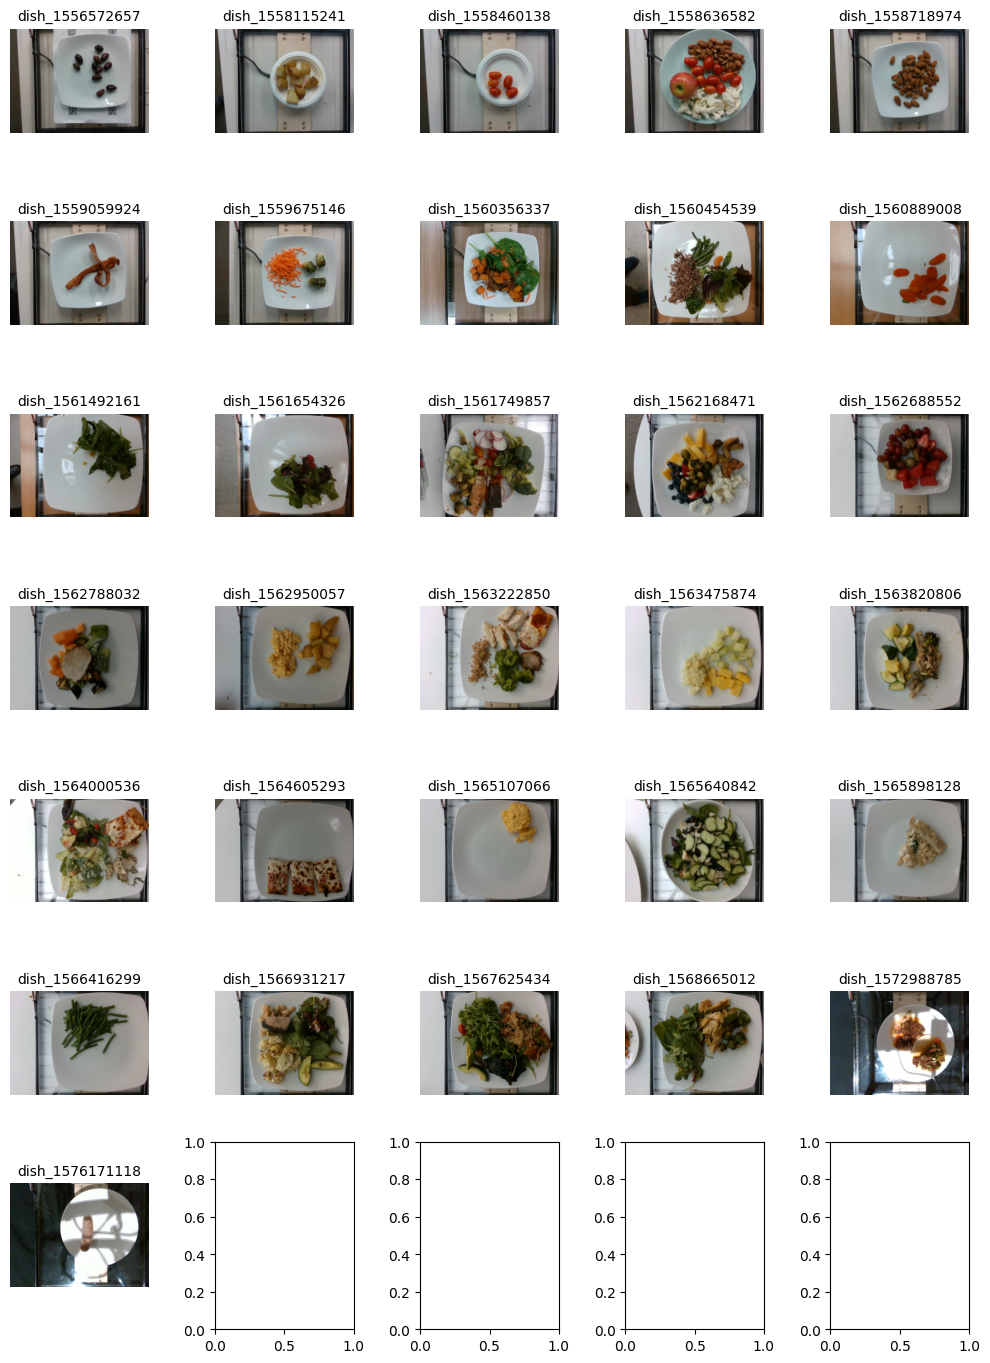

In [4]:
# посмотрим на изображения. возможно, это подскажет нам следующие шаги обработки
images = {}

# выведем несколько примеров
counter = 0
for subfolder in paths.iterdir():
    if subfolder.is_dir():
        if counter % int(count_dirs/30) == 0:
            image_path = next(subfolder.glob('*.png'), None)
            images[subfolder.name] = Image.open(image_path).convert('RGB')
        counter += 1

num_classes = len(images)

# считаем необходимое кол-во столбцов и колонок
cols = 5
rows = (num_classes + cols -1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 2*rows))
axes = axes.flatten()

for idx, (class_name, image) in enumerate(images.items()):
    
    axes[idx].imshow(image)
    axes[idx].set_title(class_name, fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


1. видно, что в целом изображения уже более менее центрированы
2. изображения отличаются по освещению, фону, видом тарелки и расположению продуктов на тарелке
3. разное освещение указывает нам на то, что нужно обязательно применить изменение экспозиции при аугментации
4. большие шумы добавлять, наверное, не нужно - их алгоритм может принять за кусочки пищи
5. стирание областей тоже, наверное, применять не стоит (либо очень незначительное) - иначе может потеряться важная информация
6. небольшой цветовой шум приветствуется

In [5]:
# обзор прочих данных
df_train, df_test = create_dataframes(cfg)

display(df_train.head())
display(df_train.info())
display(df_test.head())
display(df_test.info())

,dish_id,total_calories,total_mass,split,ingredients_string,image_path
0,dish_1561662054,419.438782,292.0,train,pepper;white rice;mixed greens;garlic;soy sauc...,C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...
1,dish_1560455030,20.590000,103.0,train,cherry tomatoes;cucumbers;baby carrots,C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...
2,dish_1558372433,74.360001,143.0,train,deprecated,C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...
3,dish_1565640549,45.482903,139.0,train,tomatoes;cilantro;olive oil;mustard greens;lem...,C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...
4,dish_1563207364,309.269989,271.0,train,scrambled eggs;yam;grapes;egg whites;olive oil...,C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2755 entries, 0 to 2754
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   dish_id             2755 non-null   object 
 1   total_calories      2755 non-null   float64
 2   total_mass          2755 non-null   float64
 3   split               2755 non-null   object 
 4   ingredients_string  2755 non-null   object 
 5   image_path          2755 non-null   object 
dtypes: float64(2), object(4)
memory usage: 129.3+ KB


None

,dish_id,total_calories,total_mass,split,ingredients_string,image_path
0,dish_1561662216,300.794281,193.0,test,soy sauce;garlic;white rice;parsley;onions;bro...,C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...
1,dish_1562008979,382.936646,290.0,test,jalapenos;lemon juice;pork;wheat berry;cabbage...,C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...
2,dish_1561739238,274.190002,257.0,test,egg whites;hash browns;berries;sweet potato,C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...
3,dish_1562691032,419.681702,415.0,test,berries;olive oil;pineapple;scrambled eggs;roa...,C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...
4,dish_1558549773,2.300000,10.0,test,spinach (raw),C:\Users\bagen\OneDrive\Рабочий стол\Data Anal...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   dish_id             507 non-null    object 
 1   total_calories      507 non-null    float64
 2   total_mass          507 non-null    float64
 3   split               507 non-null    object 
 4   ingredients_string  507 non-null    object 
 5   image_path          507 non-null    object 
dtypes: float64(2), object(4)
memory usage: 23.9+ KB


None

# Архитектура

В данной задаче у нас есть разнородные данные:
 - изображение
 - текстовое описание
 - общую массу

Все эти параметры влияют на конечное значение кол-ва калорий, поэтому наша мультимодальная модель будет работать со всеми тремя типами данных

Архитектура следующая:
1. Текст. Т.к. описание короткое, то нет смысла использовать трансформерные модели для получения эмбеддингов - глубокий контекст нам не нужен. Применим Fasttext
2. Изображение. Здесь будет наибольшая вариативность. После стандартной аугментации сможем давать тензор изображения на вход разным моделям.
3. Масса. Создадим простую полносвязную сеть, которая будет переводить 1 число в N вектор. По умолчанию оставим N=1
4. Решающая голова (head). 
 - Перед подачей всех признаков нормализуем эмбеддинги всех признаков, затем сделаем активацию через Relu
 - Используем поэлементное умножение всех признаков и подадим общий вектор-представление на вход линейной части

# 2. Обучение модели и валидация

Обучим несколько моделей и сохраним только те, у которых конечный Val loss будет меньше 50

In [6]:
# выберем какую-либо модель для CV
# используем *maxxvitv2 - это современные CV модели на основе трансформеров

# 'maxxvitv2_nano_rw_256',
# 'maxxvitv2_rmlp_base_rw_224',
# 'maxxvitv2_rmlp_base_rw_384',
# 'maxxvitv2_rmlp_large_rw_224',

In [7]:
# получаем модель fasttext
ft_model = get_fasttext(cfg)

Всего параметров в модели: 23,065,726
Обучаемых параметров: 138,115
Обучение на основе модели maxxvitv2_nano_rw_256 

Epoch 01 | Train Loss: 122.3376 | Val Loss: 105.4367 | epoch time 42.62 sec
Epoch 02 | Train Loss: 88.1609 | Val Loss: 88.4685 | epoch time 37.87 sec
Epoch 03 | Train Loss: 81.9990 | Val Loss: 81.4038 | epoch time 37.87 sec
Epoch 04 | Train Loss: 79.8190 | Val Loss: 70.3533 | epoch time 37.90 sec
Epoch 05 | Train Loss: 72.7247 | Val Loss: 98.8696 | epoch time 36.20 sec
Epoch 06 | Train Loss: 72.1548 | Val Loss: 81.2738 | epoch time 36.99 sec
Epoch 07 | Train Loss: 65.8971 | Val Loss: 68.2281 | epoch time 37.71 sec
Epoch 08 | Train Loss: 64.2182 | Val Loss: 59.1639 | epoch time 37.94 sec
Epoch 09 | Train Loss: 62.6414 | Val Loss: 63.0288 | epoch time 37.11 sec
Epoch 10 | Train Loss: 62.3809 | Val Loss: 65.3213 | epoch time 36.87 sec
Epoch 11 | Train Loss: 58.4136 | Val Loss: 55.3396 | epoch time 37.48 sec
Epoch 12 | Train Loss: 57.8967 | Val Loss: 56.3002 | epoch time 38

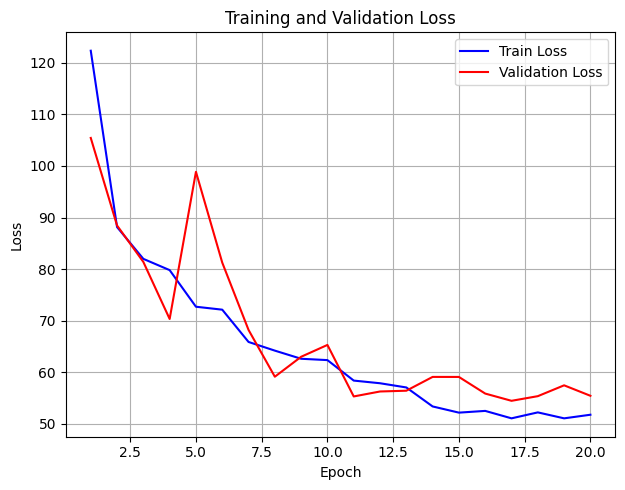

In [8]:
# начнем с базовой модели maxxvitv2_nano_rw_256

# получаем loader-ы и конфиг модели
cfg, train_loader, test_loader = prepare_loaders(df_train, df_test, ft_model, model_name='model_1_base')

##################################
# тут можно задать свои параметры для модели через cfg

# cfg.batch_size = 8
# cfg.criterion = 'Huber Loss'

##################################

# обучаем модель и получаем ее экземпляр
model_1 = start_pipeline(cfg, train_loader, test_loader)

In [10]:
# в целом с базовыми параметрами почти достигли нужной метрики. однако, если далее повышать кол-во обучаемых параметров, сильного улучшения результата не будет (проверял). обычно
# loss остается на уровне 55-60. скорее всего упираемся в ограничение модели maxxvitv2_nano_rw_256

Всего параметров в модели: 23,065,726
Обучаемых параметров: 138,115
Обучение на основе модели maxxvitv2_nano_rw_256 

Epoch 01 | Train Loss: 111.3036 | Val Loss: 93.6115 | epoch time 37.97 sec
Epoch 02 | Train Loss: 88.2089 | Val Loss: 77.1560 | epoch time 37.75 sec
Epoch 03 | Train Loss: 83.7932 | Val Loss: 67.5492 | epoch time 38.65 sec
Epoch 04 | Train Loss: 78.4911 | Val Loss: 90.5950 | epoch time 38.39 sec
Epoch 05 | Train Loss: 76.5500 | Val Loss: 65.9511 | epoch time 38.28 sec
Epoch 06 | Train Loss: 72.5437 | Val Loss: 63.1769 | epoch time 37.71 sec
Epoch 07 | Train Loss: 71.7161 | Val Loss: 62.9735 | epoch time 39.44 sec
Epoch 08 | Train Loss: 67.4758 | Val Loss: 88.4478 | epoch time 39.21 sec
Epoch 09 | Train Loss: 67.9543 | Val Loss: 58.9101 | epoch time 40.23 sec
Epoch 10 | Train Loss: 66.4903 | Val Loss: 58.6564 | epoch time 82.22 sec
Epoch 11 | Train Loss: 66.3453 | Val Loss: 65.4259 | epoch time 39.37 sec
Epoch 12 | Train Loss: 63.7341 | Val Loss: 56.0805 | epoch time 39.

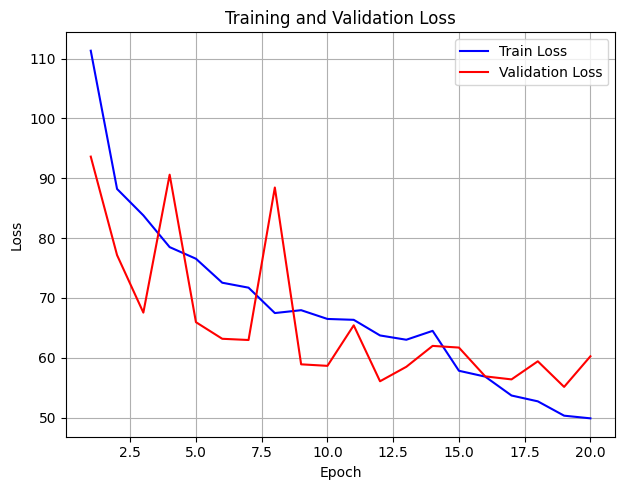

In [9]:
# применим criterion = 'Huber Loss', т.к. у него более гладкая функция и лучше сходимость
# получаем loader-ы и конфиг модели
cfg, train_loader, test_loader = prepare_loaders(df_train, df_test, ft_model, model_name='model_1_HL')

##################################
# тут можно задать свои параметры для модели через cfg

# cfg.batch_size = 8
cfg.criterion = 'Huber Loss'

##################################

# обучаем модель и получаем ее экземпляр
model_1 = start_pipeline(cfg, train_loader, test_loader)

Всего параметров в модели: 115,238,395
Обучаемых параметров: 170,883
Обучение на основе модели maxxvitv2_rmlp_base_rw_224 

Epoch 01 | Train Loss: 110.9703 | Val Loss: 81.7592 | epoch time 53.46 sec
Epoch 02 | Train Loss: 87.0317 | Val Loss: 71.7088 | epoch time 52.83 sec
Epoch 03 | Train Loss: 78.4689 | Val Loss: 66.3157 | epoch time 53.01 sec
Epoch 04 | Train Loss: 72.6582 | Val Loss: 57.2105 | epoch time 52.82 sec
Epoch 05 | Train Loss: 70.8726 | Val Loss: 56.8952 | epoch time 52.95 sec
Epoch 06 | Train Loss: 69.9982 | Val Loss: 55.9164 | epoch time 54.81 sec
Epoch 07 | Train Loss: 67.9513 | Val Loss: 72.0495 | epoch time 55.86 sec
Epoch 08 | Train Loss: 68.3671 | Val Loss: 56.7320 | epoch time 55.62 sec
Epoch 09 | Train Loss: 60.2858 | Val Loss: 53.6365 | epoch time 53.59 sec
Epoch 10 | Train Loss: 58.0148 | Val Loss: 48.6240 | epoch time 53.04 sec
Лучшая модель с val_loss=48.6240 сохранена в C:\Users\bagen\OneDrive\Рабочий стол\Data Analyst\Deep Learning\dl_sprint_4\results\best_m

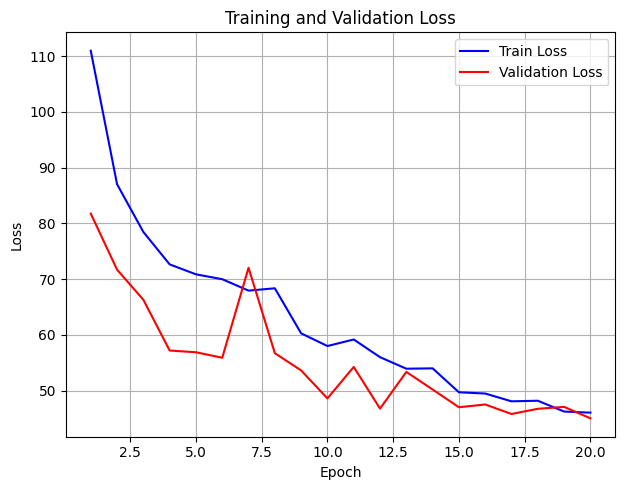

In [ ]:
# используем более продвинутую модель maxxvitv2_rmlp_base_rw_224
# получаем loader-ы и конфиг модели
cfg, train_loader, test_loader = prepare_loaders(df_train, df_test, ft_model, image_model_name='maxxvitv2_rmlp_base_rw_224', resize=224, model_name='model_2_base')

##################################
# тут можно задать свои параметры для модели через cfg

# cfg.batch_size = 8
# cfg.criterion = 'Huber Loss'

##################################

# обучаем модель и получаем ее экземпляр
model_2 = start_pipeline(cfg, train_loader, test_loader)

In [42]:
r = get_top_k_errors(model_2, test_loader, df_test, 5)
r

,dish_id,true_calories,pred_calories,abs_error
298,dish_1558549806,781.958008,295.937317,486.020691
13,dish_1558720236,887.823059,409.130463,478.692596
141,dish_1565811139,902.200012,495.851868,406.348145
170,dish_1566501594,508.048981,130.152969,377.895996
302,dish_1565030391,609.333923,334.263123,275.070801


In [43]:
selected_subfolders = [sf for sf in paths.iterdir() if sf.is_dir() and sf.name in list(r.dish_id)]

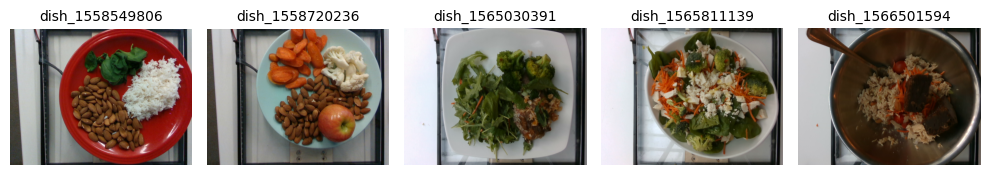

,dish_id,abs_error,true_calories,pred_calories,ingredients_string
0,dish_1558720236,478.692596,887.823059,409.130463,apple;carrot;cauliflower;almonds
1,dish_1565811139,406.348145,902.200012,495.851868,carrot;goat cheese;olive oil;broccoli;spinach (raw);chicken
2,dish_1566501594,377.895996,508.048981,130.152969,brownies
3,dish_1558549806,486.020691,781.958008,295.937317,almonds;white rice;spinach (raw)
4,dish_1565030391,275.070801,609.333923,334.263123,white rice;garlic;orange juice;onions;cucumbers;kale;green onions;lettuce;soy sauce;pepper;cherry tomatoes;beef;vinegar;olive oil;broccoli;lime;salt;chili;mixed greens


In [47]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2*rows))
axes = axes.flatten()

for idx, subfolder in enumerate(selected_subfolders):
    image_path = next(subfolder.glob('*.png'), None)
    if image_path:
        image = Image.open(image_path).convert('RGB')
        axes[idx].imshow(image)
        axes[idx].set_title(subfolder.name, fontsize=10)
        axes[idx].axis('off')
    else:
        axes[idx].axis('off')  # если нет png, просто пусто

plt.tight_layout()
plt.show()


with pd.option_context('display.max_colwidth', None):
    display(df_test.merge(r, on='dish_id', how='inner')[['dish_id', 'abs_error', 'true_calories', 'pred_calories', 'ingredients_string']])

## Выводы
1. Для 3 из 5 наихудших результатов заметно, что цвет тарелки отличался от белого.
2. В 2 худших результатах есть орехи на тарелке. Возможно, модель считывает их как гречку или другой продукт, которые обладает меньшей калорийностью. Это вероятный сценарий, если учесть, что на вход мы подаем изображением в 224 пикселя - важные мелкие детали могут сливаться.
3. В 3, 4 и 5 случае заметим, что еда "навалена" друг на друга - это значит, что калорийность не прямо пропорциональна занимаемой площади, как в общем случае. Также некоторые ингридиенты модель просто не видит
4. В 5 описание не соответствует изображению
5. В 3 случае у нас, кажется, салат. Возможно, вся калорийность находится в заправке, которую модель не может различить